# Aula 04 - Aprendizagem de Máquina (Parte III)

## Análise de Regressão

Nesta aula, veremos como a análise de regressão pode ajudar a entender o comportamento dos dados, a prever os valores dos dados (contínuos ou discretos) e a encontrar preditores importantes (modelos esparsos). Apresentamos três modelos de regressão diferentes: regressão linear simples, regressão linear múltipla e regressão polinomial. Avaliamos os resultados da análise **qualitativamente** por meio do pacote de visualização Seaborn e **quantitativamente** por meio da biblioteca scikit-learn, que fornece medidas de validação, além de outros recursos. Usamos apresentar três casos práticos usando dados reais:

* Caso prático 1: Extensão do gelo marinho e mudança climática
* Caso prático 2: Previsão do preço de um mercado de dados de novos imóveis


In [10]:
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1, rc={"lines.linewidth": 2,'font.family': [u'times']})


import matplotlib.pylab as plt
%matplotlib inline 
plt.style.use('seaborn-whitegrid')
#plt.rc('text', usetex = True)
plt.rc('font', family = 'times')
plt.rc('xtick', labelsize = 10) 
plt.rc('ytick', labelsize = 10) 
plt.rc('font', size = 12) 
plt.rc('figure', figsize = (12, 5))

In [11]:
import numpy as np

## Regressão Linear Simples e Múltipla

O modelo de regressão mais simples que podemos imaginar é o **modelo linear**, onde a resposta $\textbf{y}$ depende linearmente das covariáveis $\textbf{x}_i$.

Na regressão linear simples, com uma única variável, descrevemos a relação entre o preditor e a resposta em uma linha reta. O modelo é:

$$ \textbf{y}  =  a_0+ a_1 \textbf{x}_1 $$

O parâmetro $a_0$ é chamado de constante ou *ponto de interceptação*.

No caso da regressão linear *múltipla* nós estendemos essa ideia ajustando um hiperplano m-dimensional aos nossos preditores m.

$$ \textbf{y}  =  a_0 + a_1 \textbf{x}_1  + a_2 \textbf{x}_2  + \dots + a_m \textbf{x}_{m} $$

Os $a_i$ são chamados de *parâmetros* do modelo ou coeficientes.


**Exemplo**: O preço do seguro depende da experiência do motorista?
Dadas as informações a seguir, os preços mensais do seguro automotivo ($\textbf{y}$) e a experiência dos motoristas em anos ($\textbf{x}_{1}$) de um conjunto de n exemplos, podemos construir um modelo linear para responder a essa pergunta. Também podemos prever o preço mensal do seguro automóvel para um motorista com 10 anos de experiência.



Vamos gerar um conjunto de dados para ilustrar a regressão linear simples.

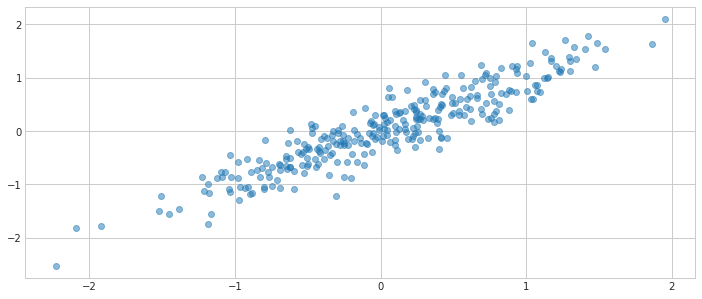

In [12]:
X1 = np.random.randn(300, 2)  # Pontos randômicos gerados com uma distribuição “normal” (Gaussiana)
A = np.array([[0.6, .4], [.4, 0.6]])
X2 = np.dot(X1, A)
plt.plot(X2[:, 0], X2[:, 1], "o", alpha = 0.5)

Podemos criar um modelo linear para explicar os dados.

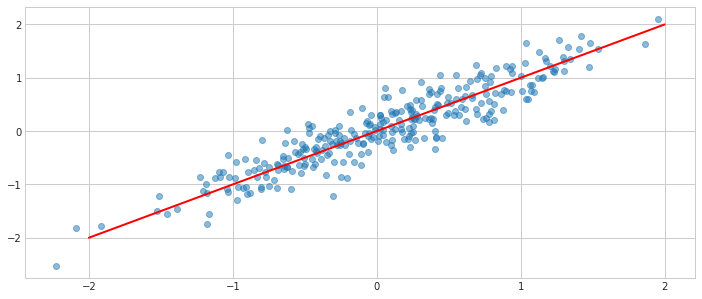

In [13]:
model = [0+1*x for x in np.arange(-2,3)]
plt.plot(X2[:, 0], X2[:, 1], "o", alpha = 0.5);
plt.plot(np.arange(-2,3), model, 'r');
plt.show()
# A linha vermelha representa os valores previstos para este modelo

Mas existem outros modelos lineares. Qual é o melhor modelo para um conjunto de amostras?

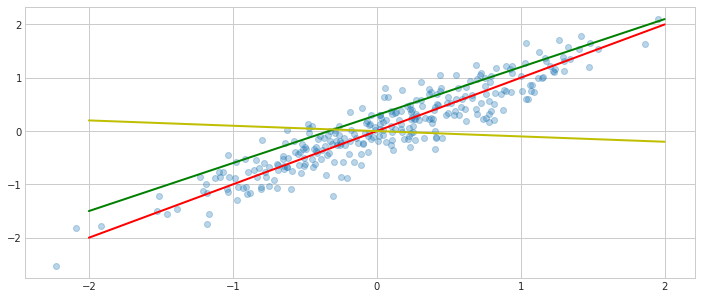

In [14]:
plt.plot(X2[:, 0], X2[:, 1], "o", alpha = 0.3);
# Podemos usar vários parâmetros e não sabemos qual é o melhor modelo
model1 = [0+1*x for x in np.arange(-2,3)]
model2 = [0.3+0.9*x for x in np.arange(-2,3)]
model3 = [0-0.1*x for x in np.arange(-2,3)]
plt.plot(np.arange(-2,3), model1, 'r')
plt.plot(np.arange(-2,3), model2, 'g')
plt.plot(np.arange(-2,3), model3, 'y')
plt.savefig("plots/ExSimpleRegModels.png", dpi = 300, bbox_inches = 'tight')

### Mínimos quadrados

A estratégias dos mínimos quadrados (Ordinary Least Squares - OLS) é o **estimador** mais simples e mais comum para avaliar os coeficientes $a$'s da regressão linear simples: $\textbf{y} = a_0+a_1 \textbf{x}$. 
Eles são calculados de forma a minimizar o **quadrado da distância entre os valores previstos e os valores reais**. 

Dado o conjunto de exemplos $(\textbf{x},\textbf{y})$, o objetivo é minimizar:

$$ ||a_0 + a_1 \textbf{x} -  \textbf{y} ||^2 = \sum_{j=1}^n (a_0+a_1 x_{j} -  y_j )^2,$$ com respeito $a_0, a_1$.

Essa expressão é frequentemente chamada de **soma dos erros quadrados de previsão** (sum of squared errors of prediction - SSE).


### Caso prático 1: Extensão do gelo marinho e mudança climática

Queremos responder a seguinte pergunta: houve uma diminuição na quantidade de gelo polar nos últimos anos?

Para isso, usaremos as medições da extensão do gelo marinho da [National Snow & Ice Data Center](https://nsidc.org/data/seaice\_index/archives.html).

Executaremos os seguintes passos:

1) Leitura e limpeza dos dados.
O arquivo 'SeaIce.txt' é um conjunto de dados separados por ``Tab``, contendo:
    * Year:	ano com 4 sígitos
    * mo:	mês com 2 dígitos
    * data_type:	entrada do dataset (Goddard/NRTSI-G)
    * region:	hemisfério da área (N: Northern; S: Southern)
    * extent:	Extensão do gelo marinho em milhões de KM quadrados
    * area:	Área de gelo marinho em milhões de KM quadrados


In [17]:
# Carregar os dados e mostrar o conteúdo:
import pandas as pd
ice = pd.read_csv('../files/SeaIce.txt', delim_whitespace = True)
print 'shape:', ice.shape
ice.head() 

shape: (424, 6)


,year,mo,data_type,region,extent,area
0,1979,1,Goddard,N,15.54,12.33
1,1980,1,Goddard,N,14.96,11.85
2,1981,1,Goddard,N,15.03,11.82
3,1982,1,Goddard,N,15.26,12.11
4,1983,1,Goddard,N,15.10,11.92


Para calcular a anomalia para um determinado intervalo de tempo, podemos calcular a média para esse intervalo (usando o período de 1981 a 2010 para a extensão média), antes da limpeza dos dados.

In [18]:
ice.mean() 
# Observação: média negativa?!

year      1996.000000
mo           6.500000
extent     -35.443066
area       -37.921108
dtype: float64

Limpeza dos dados.

Text(0,0.5,'Extensao')

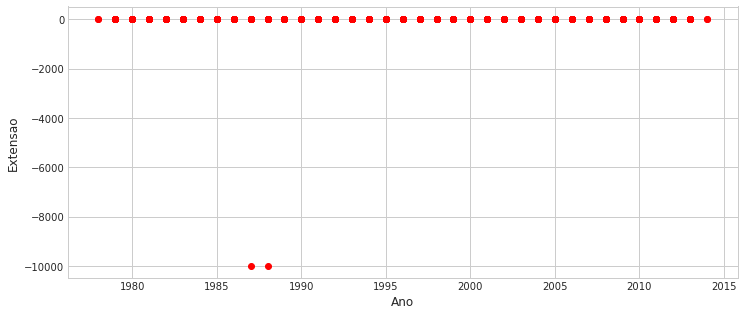

In [19]:
# Visualizando os dados
x = ice.year
y = ice.extent
plt.scatter(x, y, color = 'red')
plt.xlabel('Ano')
plt.ylabel('Extensao')

Detectamos alguns outliers e dados ausentes.

In [20]:
print 'Valores diferentes no campo data_type:', np.unique(ice.data_type.values)   # Existem valores iguais a -9999!

Valores diferentes no campo data_type: ['-9999' 'Goddard' 'NRTSI-G']


In [21]:
# Vamos ver que tipo de dados temos além de Goddard e NRTSI-G 
print ice[(ice.data_type != 'Goddard')
          & (ice.data_type != 'NRTSI-G')]

     year  mo data_type region  extent    area
9    1988   1     -9999      N -9999.0 -9999.0
397  1987  12     -9999      N -9999.0 -9999.0


shape: (422, 6)


Text(0,0.5,'Extensao')

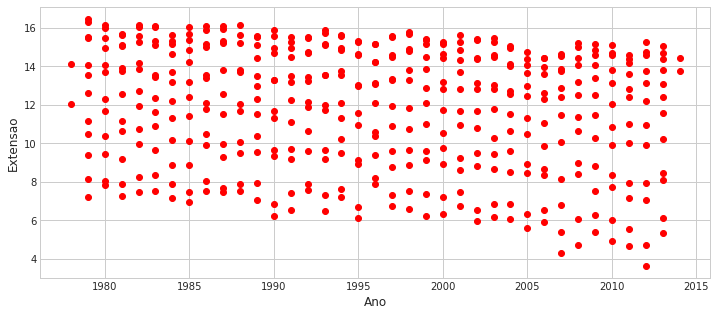

In [22]:
# Agora é fácil limpar os dados e visualizá-los novamente:
ice2 = ice[ice.data_type != '-9999']
print 'shape:', ice2.shape
# And repeat the plot
x = ice2.year
y = ice2.extent
plt.scatter(x, y, color = 'red')
plt.xlabel('Ano')
plt.ylabel('Extensao')

2) Para calcular a tendência para um determinado intervalo de tempo (mês), precisamos normalizar os dados.

A função ``lmplot()`` do pacote Seaborn destina-se a explorar relações lineares de diferentes formas em conjuntos de dados multidimensionais. A entrada de dados deve ser do tipo ``DataFrame`` (pandas). Para representá-las, fornecemos os nomes das variáveis preditoras e de resposta junto com o conjunto de dados.

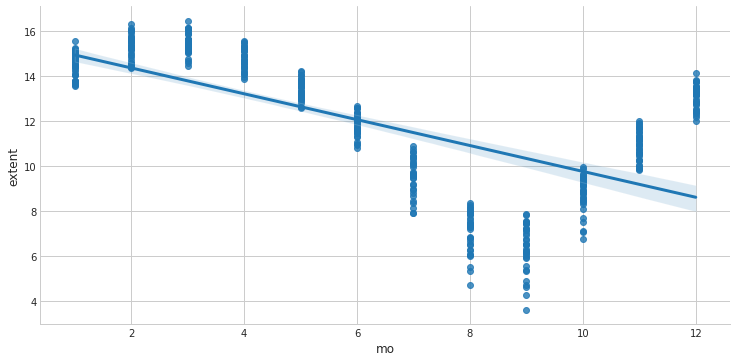

In [23]:
sns.lmplot("mo", "extent", ice2, size = 5.2, aspect = 2);
plt.savefig("plots/IceExtentCleanedByMonth.png", dpi = 300, bbox_inches = 'tight')

In [24]:
# Calcular a média para cada mês.
grouped = ice2.groupby('mo')
month_means = grouped.extent.mean()
month_variances = grouped.extent.var()
print 'Medias:', month_means
print 'Variancias:',month_variances

Medias: mo
1     14.479429
2     15.298889
3     15.491714
4     14.766000
5     13.396000
6     11.860000
7      9.601143
8      7.122286
9      6.404857
10     8.809143
11    10.964722
12    13.059429
Name: extent, dtype: float64
Variancias: mo
1     0.304906
2     0.295804
3     0.237209
4     0.215378
5     0.189901
6     0.247918
7     0.679175
8     0.824577
9     1.143902
10    0.630361
11    0.412511
12    0.284870
Name: extent, dtype: float64


Podemos calcular a média para esse intervalo de tempo (usando o período de 1981 a 2010 para a extensão média) e subtraí-la da extensão média para esse intervalo. Este valor deve ser convertido para a diferença percentual dividindo-o pela média de 1981-2010 e multiplicando por 100.

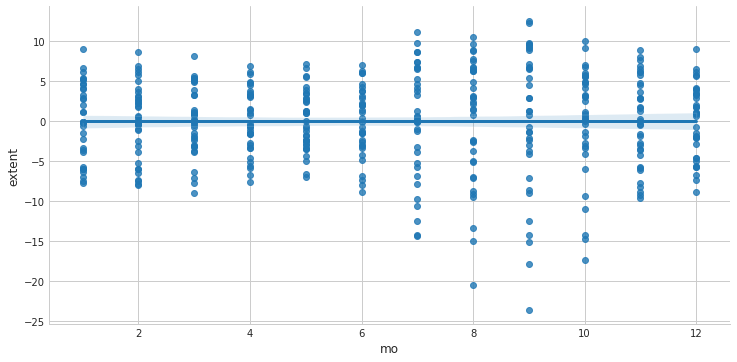

In [25]:
# Normalização dos dados
for i in range(12):
    ice2.extent[ice2.mo == i+1] = 100*(ice2.extent[ice2.mo == i+1] - month_means[i+1])/month_means.mean()
    
sns.lmplot("mo", "extent", ice2, size = 5.2, aspect = 2);
plt.savefig("plots/IceExtentNormalizedByMonth.png", dpi = 300, bbox_inches = 'tight')

In [26]:
print 'media:', ice2.extent.mean()
print 'variancia:', ice2.extent.var()

media: -6.448764639718445e-15
variancia: 31.983239774968794


3) Esses valores podem ser plotados para toda a série temporal ou para determinados meses.

Vamos considerar o ano inteiro.

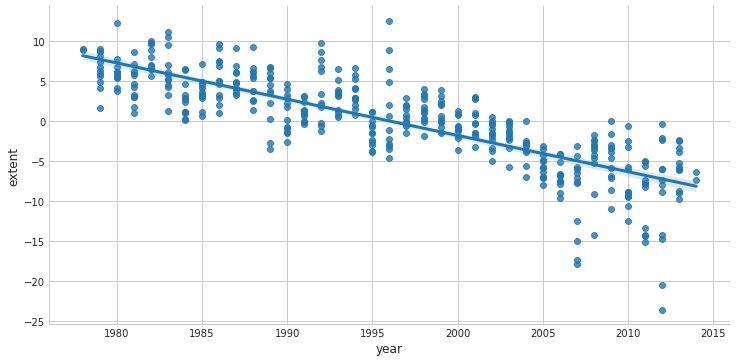

In [27]:
sns.lmplot("year", "extent", ice2,size = 5.2, aspect = 2);
plt.savefig("plots/IceExtentAllMonthsByYearlmplot.png", dpi = 300, bbox_inches = 'tight')

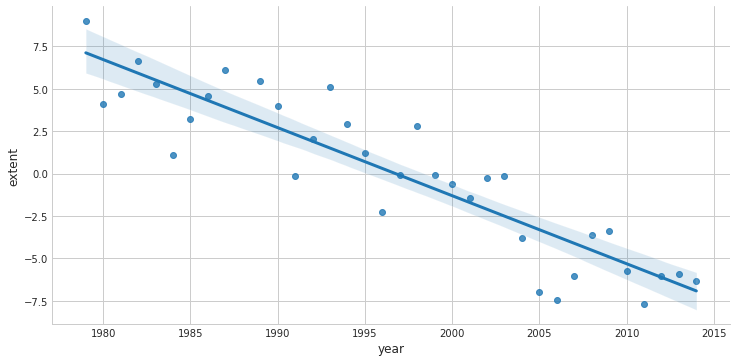

In [28]:
#Para janeiro
jan = ice2[ice2.mo == 1];
sns.lmplot("year", "extent", jan,size = 5.2, aspect = 2);

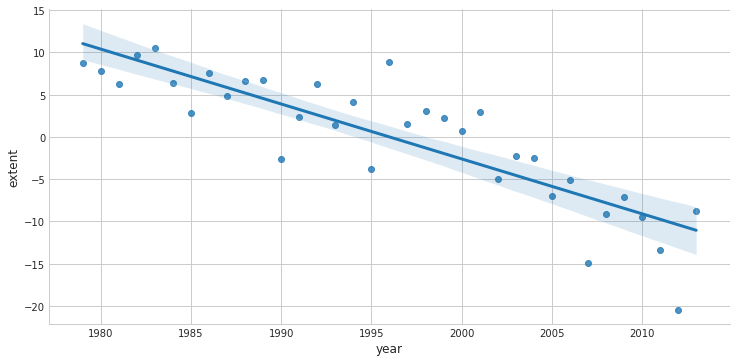

In [29]:
# Para agosto
aug = ice2[ice2.mo == 8]
sns.lmplot("year", "extent", aug,size = 5.2, aspect = 2);

In [30]:
# Calcular o coeficiente de correlação de Pearson e o p-value, para testar a correlação.
import scipy.stats
scipy.stats.pearsonr(ice2.year.values, ice2.extent.values)

(-0.8183500709897177, 4.4492318168694647e-103)

4) Também podemos calcular a tendência como uma regressão linear simples e avaliá-la quantitativamente.

Para isso nós usaremos o pacote **Scikit-learn**, que fornece uma variedade de técnicas de aprendizagem de máquina supervisionadas e não supervisionadas.

Scikit-learn fornece uma interface orientada a objetos baseada no conceito de Estimador. 
O método <code>Estimator.fit</code> define o estado do estimador com base nos dados de treinamento. Normalmente, os dados são compostos por um array numpy bidimensional $X$ na forma <code>(n_samples, n_predictors)</code> que contém uma matriz de features e um array numpy unidimensional $\textbf{y}$ que contém as respostas. Alguns estimadores permitem que o usuário configure o comportamento do método de treinamento. 
Por exemplo, o estimador <code>sklearn.linear_model.LinearRegression</code> permite que o usuário especifique se deve ou não ser considerado o ponto de interceptação. Isso é feito por meio de parametrização no construtor do objeto.

Estimadores que podem fazer previsões fornecem um método chamado ``Estimator.predict``.
No caso da regressão, o método ``Estimator.predict`` irá retornar os valores de regressão previstos, $\hat{\textbf{y}}$. 

In [31]:
from sklearn.linear_model import LinearRegression

est = LinearRegression(fit_intercept = True)

x = ice2[['year']]
y = ice2[['extent']]

est.fit(x, y)

print "Coeficientes:", est.coef_
print "Interceptação:", est.intercept_

Coeficientes: [[-0.45275459]]
Interceptação: [903.71640207]


Nós podemos avaliar a qualidade do modelo calculando a média dos mínimos quadrados ($MSE$) e o coeficiente de determinação ($R^2$) do modelo.
O coeficiente $R^2$ é definido como $(1 - \textbf{u}/\textbf{v})$, onde $\textbf{u}$ é o valor residual da soma dos quadrados $\sum (\textbf{y} - \hat{\textbf{y}})^2$ e $\textbf{v}$ é a regressão da soma dos quadrados $\sum (\textbf{y} - \bar{\textbf{y}})^2$, onde $\bar{\textbf{y}}$ é a média.
O melhor valor possível para $R^2$ é 1.0: quanto menor o valor, pior o modelo.
Essas métricas podem fornecer uma resposta quantitativa à pergunta que fizemos: há uma tendência negativa na evolução da extensão do gelo marinho nos últimos anos?

MSE: 10.539131639803449
R^2: 0.5067870382100239
var: extent    31.98324
dtype: float64


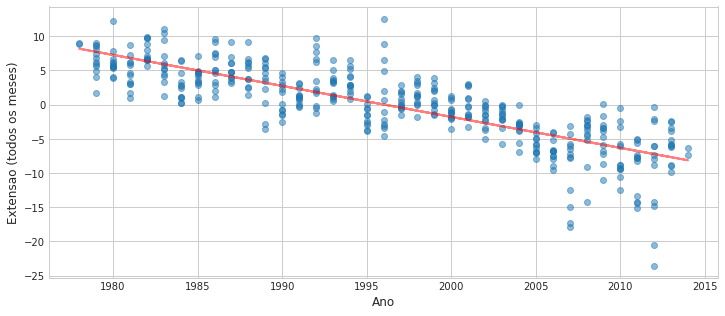

In [32]:
from sklearn import metrics

# Análise para todos os meses.
x = ice2[['year']]
y = ice2[['extent']]
model = LinearRegression()
model.fit(x, y)
y_hat = model.predict(x)
plt.plot(x, y,'o', alpha = 0.5)
plt.plot(x, y_hat, 'r', alpha = 0.5)
plt.xlabel('Ano')
plt.ylabel('Extensao (todos os meses)')
print "MSE:", metrics.mean_squared_error(y_hat, y)
print "R^2:", metrics.r2_score(y_hat, y)
print "var:", y.var()
plt.savefig("plots/IceExtentLinearRegressionAllMonthsByYearPrediction.png", dpi = 300, bbox_inches = 'tight')

Nós podemos concluir que os dados mostram uma tendência negativa de longo prazo nos últimos anos.

MSE: 3.839516075286746
R^2: 0.781063604139622


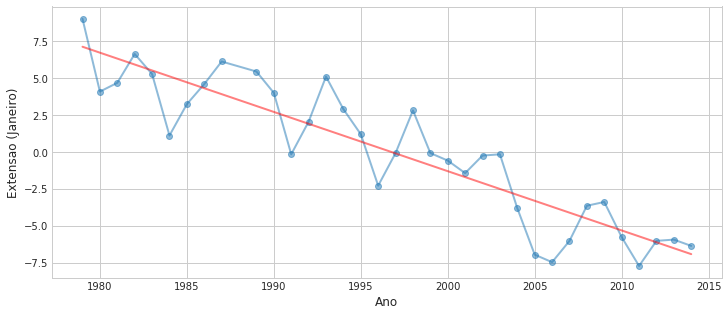

In [33]:
# Análise de um mês em particular.
x = jan[['year']]
y = jan[['extent']]

model = LinearRegression()
model.fit(x, y)

y_hat = model.predict(x)

plt.figure()
plt.plot(x, y,'-o', alpha = 0.5)
plt.plot(x, y_hat, 'r', alpha = 0.5)
plt.xlabel('Ano')
plt.ylabel('Extensao (Janeiro)')

print "MSE:", metrics.mean_squared_error(y_hat, y)
print "R^2:", metrics.r2_score(y_hat, y)

5) Nós também podemos estimar o valor da extensão para 2030. Para isso usamos a função de previsão do modelo.

In [36]:
X = [[2030]]
y_hat = model.predict(X)
j = 1 # Janeiro
y_hat = (y_hat*month_means.mean()/100) + month_means[j]
print "Previsao da extensao para Janeiro de 2030 em milhoes de KM quadrados:", y_hat

Previsao da extensao para Janeiro de 2030 em milhoes de KM quadrados: [[12.90828827]]


## Regressão Polinomial

Apesar do nome, a regressão linear pode ser usada para ajustar funções não lineares. Um modelo de regressão linear é linear nos parâmetros do modelo, não necessariamente nos preditores. Se você adicionar transformações não lineares de seus preditores ao modelo de regressão linear, o modelo será não linear nos preditores.

Uma técnica de regressão não linear muito popular é a **Regressão polinomial**, uma técnica que modela a relação entre a resposta e os preditores como um polinômio de ordem n.

$$ \textbf{y} = a_1 \phi(\textbf{x}_1) + \dots + a_m \phi(\textbf{x}_m) $$

Quanto mais alta a ordem do polinômio, maior é a capacidade de ajuste do modelo aos dados.

O uso de polinômios de ordem superior tem um preço: **complexidade computacional** e **overfitting**. Overfitting refere-se a uma situação na qual o modelo se ajusta às particularidades dos dados de treinamento e perde a capacidade de generalizar a partir do treinamento para prever dados novos.

### Caso prático 2: Previsão do preço de um mercado de dados de novos imóveis

O conjunto de dados de habitação de Boston fornece medições de registros de 13 atributos do mercado imobiliário ao redor da cidade de Boston, bem como o preço médio. Queremos prever o preço de um imóvel dado um conjunto de atributos.



Para começar, vamor carregar e visualizar os dados.

In [37]:
from sklearn import datasets
boston = datasets.load_boston()
X_boston,y_boston = boston.data, boston.target
print ('Shape of data:', X_boston.shape, y_boston.shape)

('Shape of data:', (506L, 13L), (506L,))


In [39]:
print ('Keys:', boston.keys())
print ('Nomes das features:',boston.feature_names)
print (boston.DESCR)

('Keys:', ['filename', 'data', 'target', 'DESCR', 'feature_names'])
('Nomes das features:', array(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD',
       'TAX', 'PTRATIO', 'B', 'LSTAT'], dtype='|S7'))
.. _boston_dataset:

Boston house prices dataset
---------------------------

**Data Set Characteristics:**  

    :Number of Instances: 506 

    :Number of Attributes: 13 numeric/categorical predictive. Median Value (attribute 14) is usually the target.

    :Attribute Information (in order):
        - CRIM     per capita crime rate by town
        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        - INDUS    proportion of non-retail business acres per town
        - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        - NOX      nitric oxides concentration (parts per 10 million)
        - RM       average number of rooms per dwelling
        - AGE      proportion of owner-occupied units built prior to 1

Text(0,0.5,'Qtde')

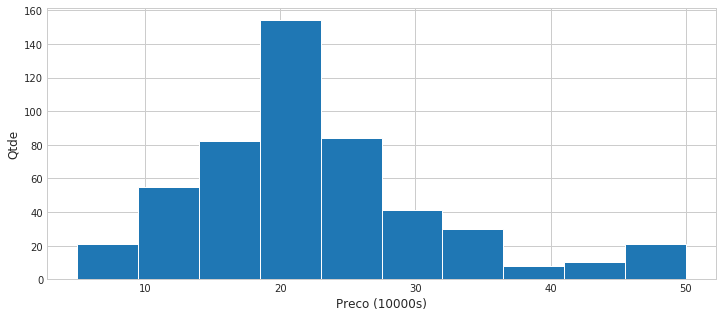

In [40]:
# Histograma de preços:
plt.hist(y_boston) 
plt.xlabel('Preco (10000s)')
plt.ylabel('Qtde')

### Visualizações

Primeiro consideramos a tarefa de prever os valores da mediana das casas na área de Boston usando como preditor um dos atributos, por exemplo, LSTAT, definido como a "proporção da população de renda mais baixa".

A visualização em Seaborn pode ser usada para mostrar essas relações lineares facilmente:

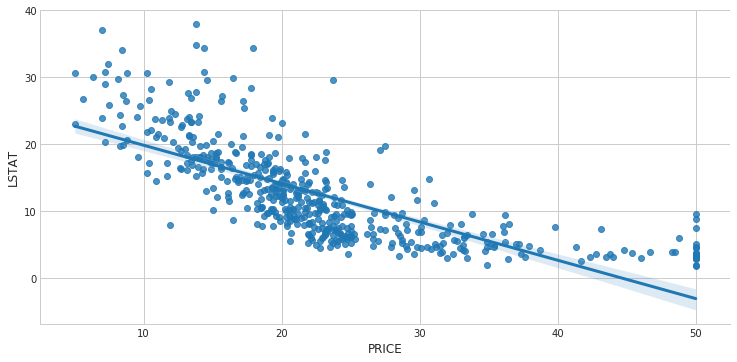

In [41]:
import pandas as pd
# Visualização das relações entre price e LSTAT
df_boston = pd.DataFrame(boston.data, columns = boston.feature_names)
df_boston['PRICE'] = boston.target
sns.lmplot("PRICE", "LSTAT", df_boston, size = 5.2, aspect = 2);
#plt.savefig("plots/lmplotBostonLSTAT.png", dpi = 300, bbox_inches = 'tight')

In [42]:
df_boston

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3.0,222.0,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0.0,0.524,6.012,66.6,5.5605,5.0,311.0,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0.0,0.524,6.172,96.1,5.9505,5.0,311.0,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0.0,0.524,5.631,100.0,6.0821,5.0,311.0,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0.0,0.524,6.004,85.9,6.5921,5.0,311.0,15.2,386.71,17.10,18.9


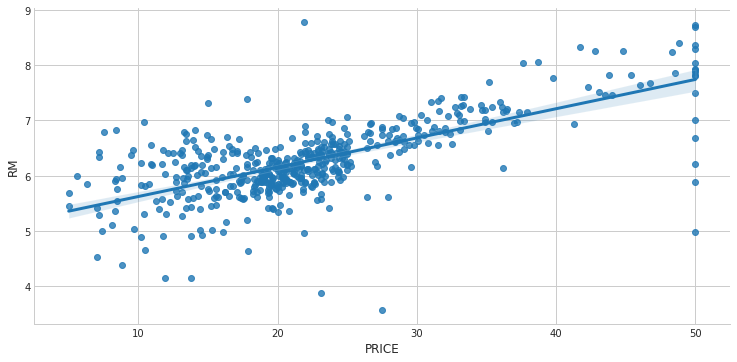

In [43]:
# Visualização das relações entre price e RM
sns.lmplot("PRICE","RM", df_boston, size = 5.2, aspect = 2);

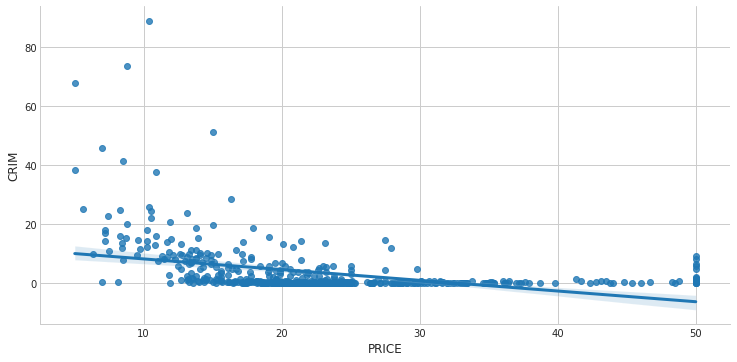

In [44]:
# Visualização das relações entre price e CRIM
sns.lmplot("PRICE", "CRIM", df_boston, size = 5.2, aspect = 2);

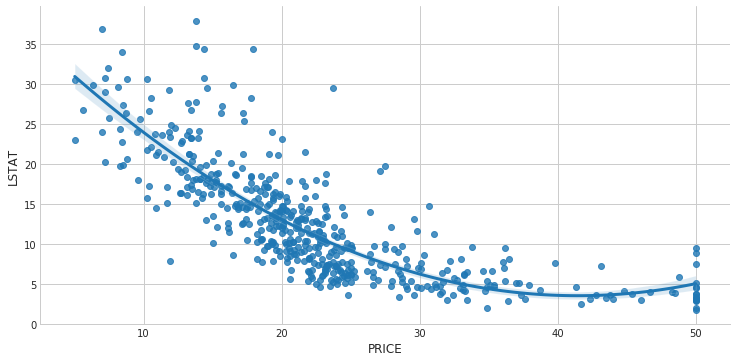

In [45]:
# modelo polinomial entre price e LSTAT (grau 2)
sns.lmplot("PRICE", "LSTAT", df_boston, order = 2, size = 5.2, aspect = 2);
plt.savefig("plots/lmplotBostonLSTAT_order2.png", dpi = 300, bbox_inches = 'tight')

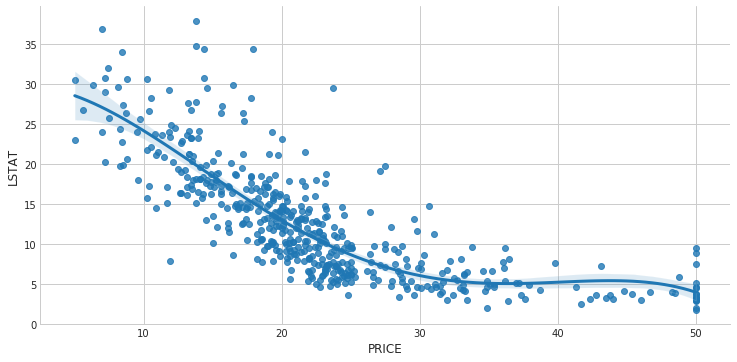

In [46]:
# modelo polinomial entre price e LSTAT (grau 4)
sns.lmplot("PRICE", "LSTAT", df_boston, order = 4, size = 5.2, aspect = 2);
plt.savefig("plots/lmplotBostonLSTATorder3.png", dpi = 300, bbox_inches = 'tight')

### Mapa de calor

Nós também podemos usar a função corrplot para criar uma matriz de correlação diagonal.

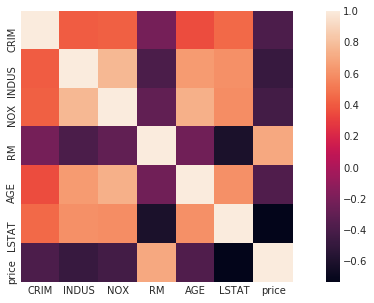

In [47]:
# Desenha um mapa de calor
indexes = [0, 2, 4, 5, 6, 12] #To plot just some of the variables
df2 = pd.DataFrame(boston.data[:,indexes], columns = boston.feature_names[indexes])
df2['price'] = boston.target
corrmat = df2.corr()
# Desenha um mapa de calor usando seaborn
sns.heatmap(corrmat, vmax = 1.0, square = True)
#plt.savefig("plots/corrplot.png", dpi = 300, bbox_inches = 'tight')


In [48]:
df2

,CRIM,INDUS,NOX,RM,AGE,LSTAT,price
0,0.00632,2.31,0.538,6.575,65.2,4.98,24.0
1,0.02731,7.07,0.469,6.421,78.9,9.14,21.6
2,0.02729,7.07,0.469,7.185,61.1,4.03,34.7
3,0.03237,2.18,0.458,6.998,45.8,2.94,33.4
4,0.06905,2.18,0.458,7.147,54.2,5.33,36.2
5,0.02985,2.18,0.458,6.430,58.7,5.21,28.7
6,0.08829,7.87,0.524,6.012,66.6,12.43,22.9
7,0.14455,7.87,0.524,6.172,96.1,19.15,27.1
8,0.21124,7.87,0.524,5.631,100.0,29.93,16.5
9,0.17004,7.87,0.524,6.004,85.9,17.10,18.9


Usando o mapa de calor da matriz de correlação, podemos observar que "RM" e "LSTAT" são as variáveis mais correlacionadas com "price".

### Gráfico de dispersão (Scatter plot)

Vamos explorar diversas variáveis com gráficos de dispersão.
O gráfico de dispersão do Pandas é uma grade de gráficos de múltiplas variáveis, que mostram a relação delas uma com as outras.

Para fins de visualização, escolhemos 3 do conjunto de 13 variáveis (LSTAT, AGE, RM):

In [52]:
print (boston.feature_names)
indexes = [5, 6, 12] # 3 of the 13 variables: LSTAT, AGE, RM.
print (boston.feature_names[indexes])

['CRIM' 'ZN' 'INDUS' 'CHAS' 'NOX' 'RM' 'AGE' 'DIS' 'RAD' 'TAX' 'PTRATIO'
 'B' 'LSTAT']
['RM' 'AGE' 'LSTAT']


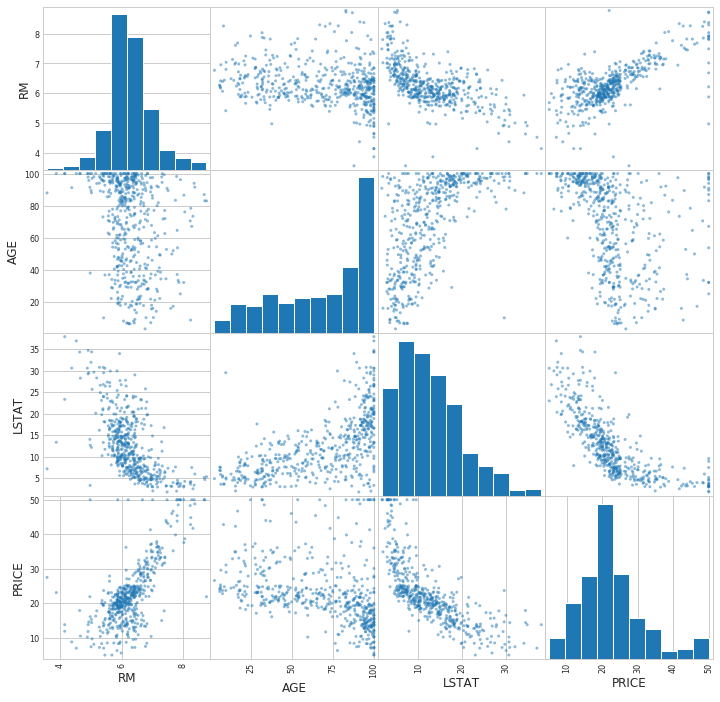

In [56]:
from pandas.plotting import scatter_matrix
indexes = [5, 6, 12]
df2 = pd.DataFrame(boston.data[:,indexes], columns = boston.feature_names[indexes])
df2['PRICE'] = boston.target
scatter_matrix(df2, figsize=(12.0, 12.0))
plt.savefig("plots/scatterplotBoston.png", dpi = 300, bbox_inches = 'tight')

### Predições

Vamos fazer previsões. Avaliação de novas amostras usando Scikit-learn.
Vamos dividir os dados em conjunto de treinamento e conjunto de teste:

In [57]:
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
train_size = int(X_boston.shape[0]/2)
X_train = X_boston[:train_size]
X_test = X_boston[train_size:]
y_train = y_boston[:train_size]
y_test = y_boston[train_size:]
print ('Tamanho dos conjuntos de treinamento e teste', X_train.shape, X_test.shape)
regr_boston = LinearRegression()
regr_boston.fit(X_train, y_train)
print ('Coeficiente e interceptação:', regr_boston.coef_, regr_boston.intercept_)
# Best possible score is 1.0, lower values are worse.
print ('Score do treinamento:', regr_boston.score(X_train, y_train))
print ('Score do teste:', regr_boston.score(X_test, y_test))
print ('MSE do treinamento: ', np.mean((regr_boston.predict(X_train) - y_train)**2))
print ('MSE do teste: ', np.mean((regr_boston.predict(X_test) - y_test)**2))

('Tamanho dos conjuntos de treinamento e teste', (253L, 13L), (253L, 13L))
('Coeficiente e intercepta\xc3\xa7\xc3\xa3o:', array([ 1.20133313,  0.02449686,  0.00999508,  0.42548672, -8.44272332,
        8.87767164, -0.04850422, -1.11980855,  0.20377571, -0.01597724,
       -0.65974775,  0.01777057, -0.11480104]), -10.017430582945298)
('Score do treinamento:', 0.8557827200735684)
('Score do teste:', -2.2527343423924795)
('MSE do treinamento: ', 9.987517325463742)
('MSE do teste: ', 303.4368629265851)


Podemos ver que todos os coeficientes obtidos são diferentes de zero, o que significa que nenhuma variável é descartada.
A seguir, tentamos construir um modelo esparso para prever o preço usando os atributos mais importantes e descartando os não iimportantes. Para fazer isso, podemos criar um regressor do tipo LASSO.

## Modelos esparsos

Freqüentemente, em problemas reais, existem variáveis não importantes nos dados, que impedem a modelagem adequada do problema e, portanto, a construção de um modelo de regressão correto. Nesses casos, um processo de seleção de variáveis é fundamental para selecionar apenas as variáveis importantes e descartar as não importantes. Isso pode ser alcançado por métodos esparsos que usam uma abordagem de penalização, como *LASSO* (least absolute shrinkage and selection operator) para reduzir alguns coeficientes do modelo para zero, descartando assim essas variáveis.


In [58]:
# Criar um regressor Lasso
from sklearn import linear_model
regr_lasso = linear_model.Lasso(alpha=.3)
regr_lasso.fit(X_train, y_train) 
print ('Coeficiente e interceptação:', regr_lasso.coef_,  regr_lasso.intercept_)

print ('Score do treinamento:', regr_lasso.score(X_train, y_train))
print ('Score do teste:', regr_lasso.score(X_test, y_test))

print ('MSE do treinamento: ', np.mean((regr_lasso.predict(X_train) - y_train)**2))
print ('MSE do teste: ', np.mean((regr_lasso.predict(X_test) - y_test)**2))

('Coeficiente e intercepta\xc3\xa7\xc3\xa3o:', array([ 0.        ,  0.01996512, -0.        ,  0.        , -0.        ,
        7.69894744, -0.03444803, -0.79380636,  0.0735163 , -0.0143421 ,
       -0.66768539,  0.01547437, -0.22181817]), -6.183241836148397)
('Score do treinamento:', 0.8449992039829642)
('Score do teste:', 0.501127529021216)
('MSE do treinamento: ', 10.73431100954422)
('MSE do teste: ', 46.538168094875665)


Agora é possível ver que o resultado do ajuste do modelo para um conjunto de coeficientes esparsos é muito melhor do que antes (usando todas as variáveis), com o Score do teste aumentando de -2.25 para 0.5. Isso demonstra que quatro das variáveis iniciais não são importantes para a previsão e de fato confundem o regressor.

In [60]:
ind = np.argsort(np.abs(regr_lasso.coef_))
print 'Ordem das variáveis (da menos para a mais importante):', boston.feature_names[ind]

Ordem das variáveis (da menos para a mais importante): ['CRIM' 'INDUS' 'CHAS' 'NOX' 'TAX' 'B' 'ZN' 'AGE' 'RAD' 'LSTAT' 'PTRATIO'
 'DIS' 'RM']


Podemos selecionar as features mais importantes com o pacote sklearn:

In [61]:
import sklearn.feature_selection as fs 
selector = fs.SelectKBest(score_func = fs.f_regression, k = 5)
selector.fit_transform(X_train, y_train)
print ('Features selecionadas:', zip(selector.get_support(), boston.feature_names)) # Mostra as features selecionadas)

('Features selecionadas:', [(False, 'CRIM'), (False, 'ZN'), (True, 'INDUS'), (False, 'CHAS'), (False, 'NOX'), (True, 'RM'), (True, 'AGE'), (False, 'DIS'), (False, 'RAD'), (False, 'TAX'), (True, 'PTRATIO'), (False, 'B'), (True, 'LSTAT')])
